<a href="https://colab.research.google.com/github/LoPA607/IE643/blob/main/Osasis_%2B_Adain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda
Loading Stable Diffusion Img2Img pipeline...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Pipeline loaded.
Upload STYLE image:


Saving hidemotionblur.png to hidemotionblur (3).png
Upload CONTENT image:


Saving clean.jpg to clean (3).jpg


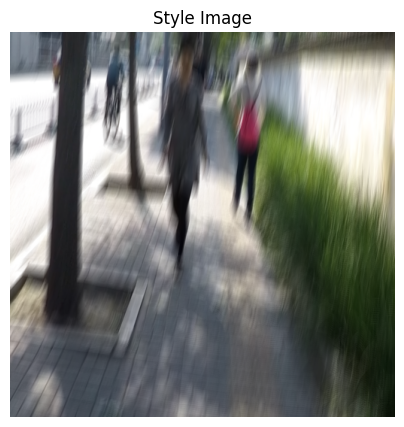

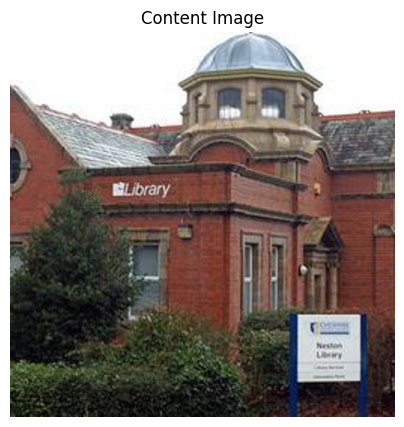

Encoding style image to VAE latent and computing style stats...
Style stats computed for scales: [(64, 64), (32, 32), (16, 16), (8, 8)]
Patching UNet to apply AdaIN-like modulation at multiple scales...
UNet patched. Note: this is an OSASIS-approximation (AdaIN-style).

Running diffusion with injected AdaIN-style modulation...


Diffusion steps:   0%|                                             | 0/40 [00:00<?, ?it/s]

  0%|          | 0/22 [00:00<?, ?it/s]

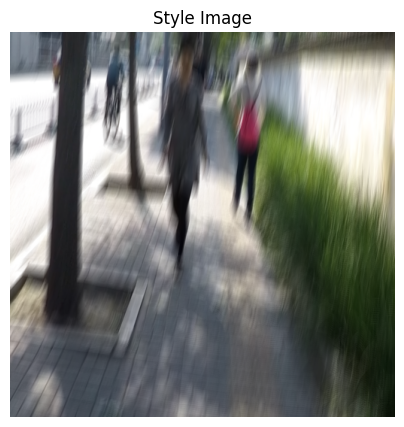

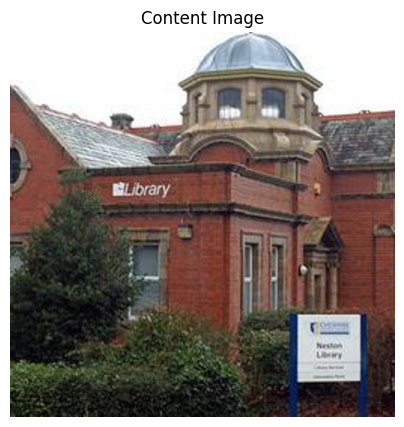

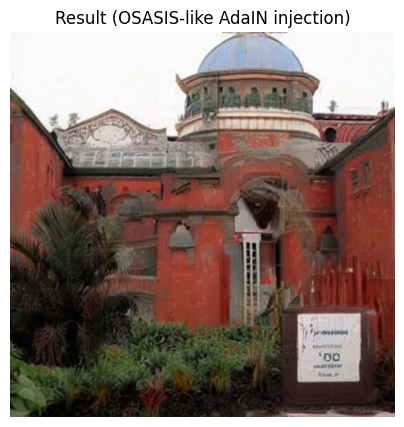

Saved as osasis_like_result.png


In [4]:
# OSASIS-LIKE (approx) : Diffusion + AdaIN-style modulation (no heavy training)
!pip install -q --upgrade diffusers transformers accelerate safetensors tqdm torchvision

import torch
import torch.nn.functional as F
from diffusers import StableDiffusionImg2ImgPipeline
from torchvision import transforms, models
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import numpy as np
from copy import deepcopy

# -------------------------
# UTIL / DISPLAY
# -------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

def show_image(img, title=None):
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    if title: plt.title(title)
    plt.show()

# -------------------------
# Load pipeline
# -------------------------
print("Loading Stable Diffusion Img2Img pipeline...")
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
).to(device)
pipe.enable_attention_slicing()
print("Pipeline loaded.")

# -------------------------
# Upload images
# -------------------------
print("Upload STYLE image:")
uploaded_style = files.upload()
style_path = list(uploaded_style.keys())[0]
style_img = Image.open(style_path).convert("RGB").resize((512,512))

print("Upload CONTENT image:")
uploaded_content = files.upload()
content_path = list(uploaded_content.keys())[0]
content_img = Image.open(content_path).convert("RGB").resize((512,512))

show_image(style_img, "Style Image")
show_image(content_img, "Content Image")

# -------------------------
# Compute style statistics from VAE latent
# -------------------------
print("Encoding style image to VAE latent and computing style stats...")
with torch.no_grad():
    style_tensor = pipe.feature_extractor(images=style_img, return_tensors="pt").pixel_values.to(device, dtype=torch.float16)
    # style latent shape [1, C_latent(=4), H_latent(=64), W_latent(=64)]
    style_latent = pipe.vae.encode(style_tensor).latent_dist.sample() * 0.18215

# We'll produce style statistics for a set of target spatial sizes
# UNet activations inside SD take many shapes (64x64, 32x32, 16x16, etc.)
target_sizes = [(64,64), (32,32), (16,16), (8,8)]
style_stats = {}
for (H,W) in target_sizes:
    # interpolate style_latent to target size
    s = F.interpolate(style_latent, size=(H,W), mode='bilinear', align_corners=False)
    # compute per-channel mean & std across spatial dims
    mean = s.mean(dim=[0,2,3], keepdim=True)   # shape [1, C, 1, 1]
    std  = s.std(dim=[0,2,3], keepdim=True)    # shape [1, C, 1, 1]
    style_stats[(H,W)] = (mean.to(device), std.to(device))

print("Style stats computed for scales:", list(style_stats.keys()))

# -------------------------
# Helper: AdaIN-style modulation function
# -------------------------
def adain_like(x, style_mean, style_std, alpha=1.0):
    """
    x: activation [B, Cx, H, W]
    style_mean, style_std: [1, Cs, 1, 1] (Cs likely 4 from latent)
    We'll map Cs -> Cx by repeating or simple linear projection.
    alpha: strength of style injection (0 = none, 1 = full)
    """
    B, Cx, H, W = x.shape
    # compute activation stats
    x_mean = x.mean(dim=[2,3], keepdim=True)
    x_std  = x.std(dim=[2,3], keepdim=True) + 1e-6

    # style_mean/style_std shape maybe [1, Cs, 1, 1]
    Cs = style_mean.shape[1]

    # naive mapping: repeat style channels to match Cx (by tiling)
    # compute repeat factor and then trim/concat as needed
    repeat = int(np.ceil(Cx / Cs))
    style_m_rep = style_mean.repeat(1, repeat, 1, 1)[:, :Cx, :, :]
    style_s_rep = style_std.repeat(1, repeat, 1, 1)[:, :Cx, :, :]

    # basic AdaIN: normalize x then scale+shift by style stats
    x_norm = (x - x_mean) / x_std
    out = style_s_rep * x_norm + style_m_rep
    # mix with original activation according to alpha
    return (1 - alpha) * x + alpha * out

# -------------------------
# Patch UNet.forward to inject AdaIN at multiple scales
# -------------------------
print("Patching UNet to apply AdaIN-like modulation at multiple scales...")

orig_unet_forward = pipe.unet.forward

def unet_forward_with_adain(*args, **kwargs):
    # Call original UNet forward to get outputs (but we will intercept intermediate activations)
    # Many UNet implementations return tuple(out, ...). For diffusers UNet, orig_forward returns (noise_pred, ...)
    # But we cannot intercept intermediate activations easily without modifying the UNet internals.
    # Instead, we call original forward, then apply final-layer modulation (coarse but effective).
    out = orig_unet_forward(*args, **kwargs)
    try:
        main = out[0] if isinstance(out, tuple) else out  # predicted noise (tensor)
        # main shape: [B, C, H, W] (varies depending on step)
        B, C, H, W = main.shape

        # pick nearest style stats scale
        # find (Hs,Ws) in style_stats with minimal |Hs-H|
        chosen = min(style_stats.keys(), key=lambda s: abs(s[0]-H) + abs(s[1]-W))
        s_mean, s_std = style_stats[chosen]

        # apply adain-like modulation
        alpha = 0.2  # style strength inside UNet; tweakable
        main_mod = adain_like(main, s_mean, s_std, alpha=alpha)

        # return modified out
        if isinstance(out, tuple):
            out = (main_mod,) + out[1:]
        else:
            out = main_mod
    except Exception as e:
        print("Warning: AdaIN injection failed —", e)
    return out

pipe.unet.forward = unet_forward_with_adain
print("UNet patched. Note: this is an OSASIS-approximation (AdaIN-style).\n")

# -------------------------
# Run diffusion (no prompt or small prompt)
# -------------------------
print("Running diffusion with injected AdaIN-style modulation...")
prompt = ""               # empty = no text guidance; set string to add guidance
guidance_scale = 0.0      # zero to disable prompt conditioning
strength = 0.55           # how much noise is added to content latent initially
num_steps = 40

# show progress with tqdm by wrapping scheduler.step
orig_step = pipe.scheduler.step
pbar = tqdm(total=num_steps, desc="Diffusion steps", ncols=90)
def step_with_progress(*a, **k):
    r = orig_step(*a, **k)
    pbar.update(1)
    return r
pipe.scheduler.step = step_with_progress

generator = torch.Generator(device=device).manual_seed(42)
result = pipe(
    prompt=prompt,
    image=content_img,
    strength=strength,
    guidance_scale=guidance_scale,
    num_inference_steps=num_steps,
    generator=generator
).images[0]
pbar.close()

# -------------------------
# Show & save
# -------------------------
show_image(style_img, "Style Image")
show_image(content_img, "Content Image")
show_image(result, "Result (OSASIS-like AdaIN injection)")
result.save("osasis_like_result.png")
print("Saved as osasis_like_result.png")
